In [3]:
import matplotlib.pyplot as plt
import os
import pandas as pd

In [4]:
df = pd.read_csv(os.path.join("data", "raw", "legal_corpus.csv"))
df

,content,metadata
0,Статья 1. Осуществление правосудия арбитражным...,{'Название нормативно-правового акта': 'АПК РФ...
1,Статья 2. Задачи судопроизводства в арбитражны...,{'Название нормативно-правового акта': 'АПК РФ...
2,Статья 3. Законодательство о судопроизводстве ...,{'Название нормативно-правового акта': 'АПК РФ...
3,Статья 4. Право на обращение в арбитражный су...,{'Название нормативно-правового акта': 'АПК РФ...
4,Статья 5. Независимость судей арбитражных суд...,{'Название нормативно-правового акта': 'АПК РФ...
...,...,...
10338,Правительство Российской Федерации постановляе...,{'Название нормативно-правового акта': 'Отдель...
10339,В соответствии с частью второй статьи 751 Угол...,{'Название нормативно-правового акта': 'Отдель...
10340,Правительство Российской Федерации постановляе...,{'Название нормативно-правового акта': 'Отдель...
10341,Зарегистрирован в Минюсте РФ 10 июля 2009 г. ...,{'Название нормативно-правового акта': 'Отдель...


### Извлечение признаков из метаданных

In [5]:
df["Название нормативно-правового акта"] = df["metadata"].apply(lambda x: eval(x).get("Название нормативно-правового акта"))

### Определение средней длины статьи по количеству слов в статье

In [9]:
print('Средняя длина статьи:', df['content'].apply(lambda x: len(str(x).split())).mean())
print('Средняя длина по нормативно-правовым актам:')
print(df.groupby(by='Название нормативно-правового акта').apply(lambda x: x['content'].apply(lambda y: len(str(y).split())).mean()))

Средняя длина статьи: 1165.2235328241322
Средняя длина по нормативно-правовым актам:
Название нормативно-правового акта
АПК РФ                                271.583744
БК РФ                                 518.564626
ГК РФ                                 180.358108
ГПК РФ                                198.538153
ГрК РФ                               1283.957746
ЖК РФ                                 466.448560
ЗК РФ                                 578.626943
КоАП РФ                               351.094690
ЛК РФ                                 261.874419
НК РФ                                1186.826245
Отдельный нормативно-правовой акт    3042.125211
СК РФ                                 177.293785
ТК РФ                                 241.564007
УК РФ                                 318.990637
УПК РФ                                293.865832
dtype: float64


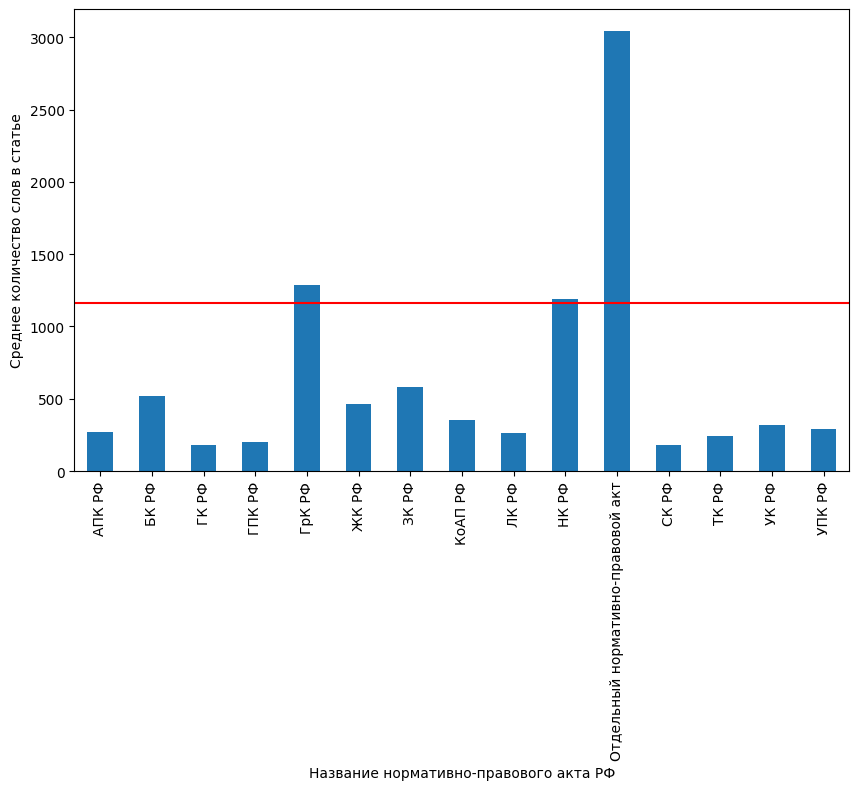

In [10]:
plt.figure(figsize=(10, 6))

grouped_docs = df.groupby(by='Название нормативно-правового акта').apply(lambda x: x['content'].apply(lambda y: len(str(y).split())).mean())
grouped_docs.plot(kind='bar')

plt.axhline(y=df['content'].apply(lambda x: len(str(x).split())).mean(), color='red')
plt.xlabel('Название нормативно-правового акта РФ')
plt.ylabel('Среднее количество слов в статье')
plt.show()

### Определение средней длины статьи по количеству символов в статье

In [11]:
print('Средняя длина статьи:', df['content'].apply(lambda x: len(str(x))).mean())
print('Средняя длина по нормативно-правовым актам:')
print(df.groupby(by='Название нормативно-правового акта').apply(lambda x: x['content'].apply(lambda y: len(str(y))).mean()))

Средняя длина статьи: 9343.344097457217
Средняя длина по нормативно-правовым актам:
Название нормативно-правового акта
АПК РФ                                2102.273399
БК РФ                                 4266.034014
ГК РФ                                 1408.634459
ГПК РФ                                1517.383534
ГрК РФ                               10583.542254
ЖК РФ                                 3689.386831
ЗК РФ                                 4601.357513
КоАП РФ                               2752.499115
ЛК РФ                                 2090.567442
НК РФ                                 9241.252734
Отдельный нормативно-правовой акт    24567.530881
СК РФ                                 1348.536723
ТК РФ                                 1991.723562
УК РФ                                 2303.305243
УПК РФ                                2279.688730
dtype: float64


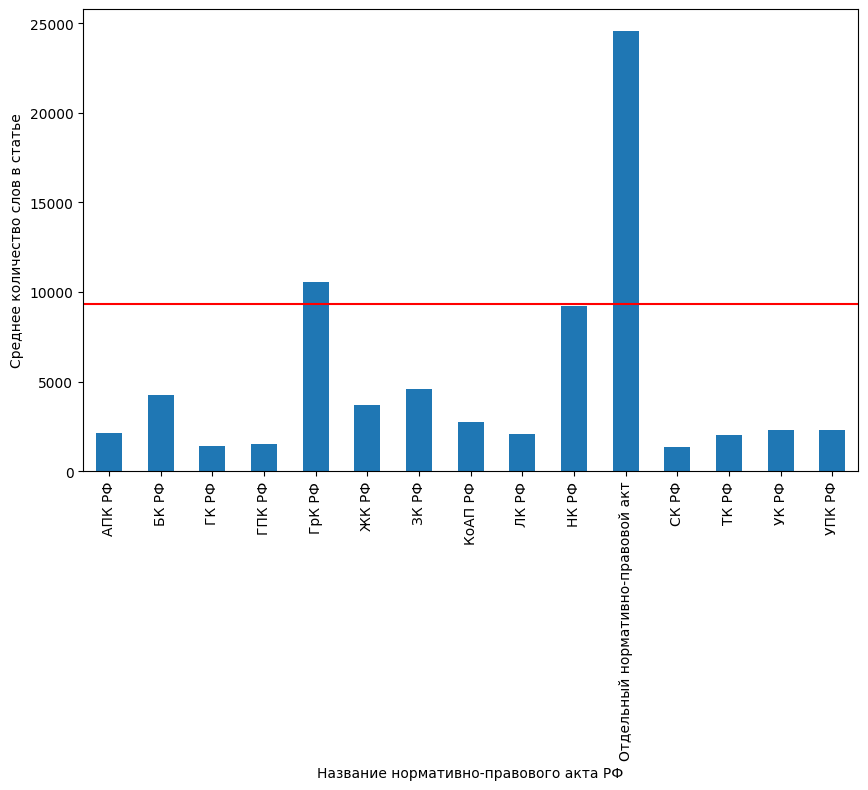

In [12]:
plt.figure(figsize=(10, 6))

grouped_docs = df.groupby(by='Название нормативно-правового акта').apply(lambda x: x['content'].apply(lambda y: len(str(y))).mean())
grouped_docs.plot(kind='bar')

plt.axhline(y=df['content'].apply(lambda x: len(str(x))).mean(), color='red')
plt.xlabel('Название нормативно-правового акта РФ')
plt.ylabel('Среднее количество слов в статье')
plt.show()

### Распределение статей по классам

In [13]:
documents = df['Название нормативно-правового акта'].value_counts()

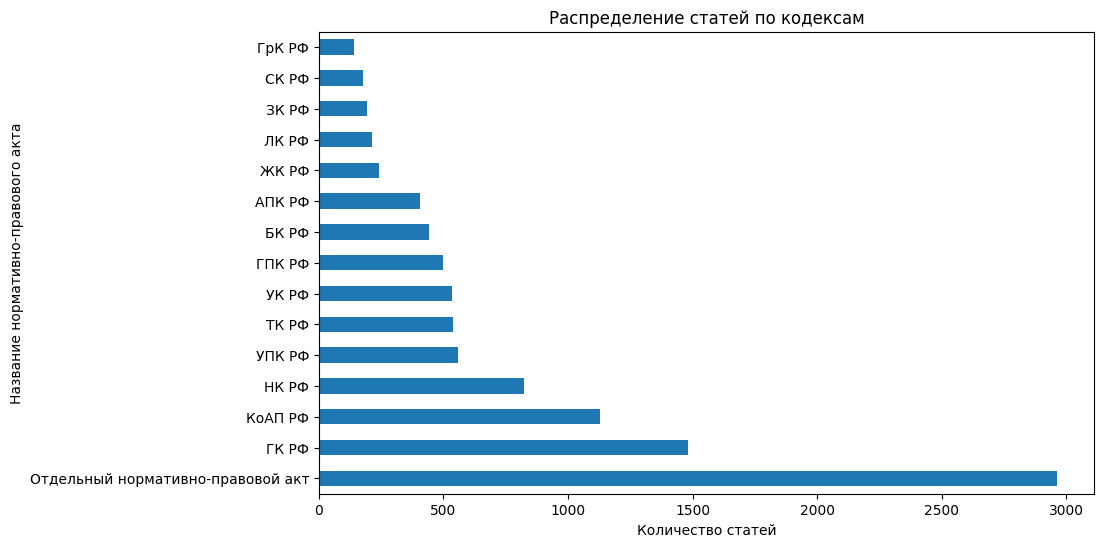

In [14]:
plt.figure(figsize=(10, 6))
plt.title("Распределение статей по кодексам")
documents.plot(kind='barh')
plt.xlabel('Количество статей')
plt.show()

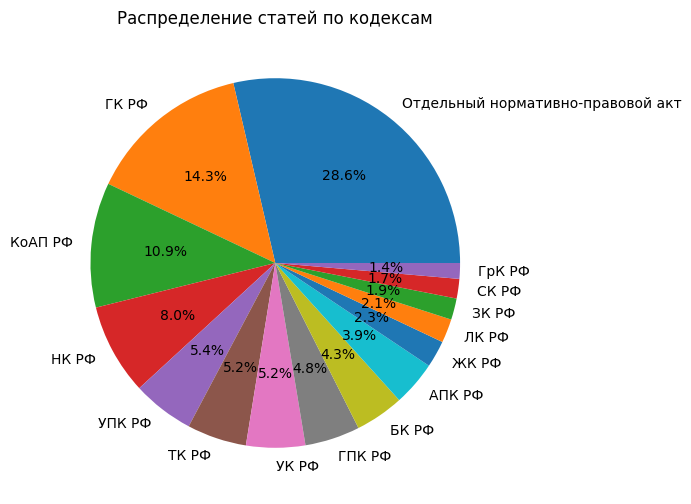

In [15]:
plt.figure(figsize=(10, 6))
plt.title("Распределение статей по кодексам")
documents.plot(kind='pie', autopct='%1.1f%%')
plt.show()

Итог: больше всего разрозненных статей.

In [26]:
import string

In [28]:
all_words = df['content'].str.split().explode().apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)).lower())
long_words = all_words[all_words.apply(lambda x: len(x) >= 3)]

print("Топ-20 самых частых слов:")
for word, count in long_words.value_counts().head(20).items():
    print(f"{word}: {count}")

Топ-20 самых частых слов:
федерации: 129623
или: 114232
российской: 110904
статьи: 69750
для: 54509
при: 53655
федерального: 38692
настоящего: 38058
соответствии: 35462
года: 34694
статья: 33514
части: 33337
закона: 30310
также: 29334
если: 28020
его: 27173
кодекса: 26576
лиц: 25383
государственной: 24803
федеральным: 24468
